In [1]:
import pandas as pd

In [2]:
medical_df = pd.read_csv('insurance.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Exploratory Analysis and Visualization

In [5]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [7]:
medical_df['age'].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [8]:
# Age Distribution
fig = px.histogram(medical_df, x='age', nbins=47, marginal='box', title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [9]:
fig = px.histogram(medical_df, x='bmi', marginal='box', color_discrete_sequence=['red'], title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()


In [10]:
# Annual medical charges by smoker
fig = px.histogram(medical_df, x='charges', marginal='box', color='smoker', color_discrete_sequence=['green', 'grey'], title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [11]:
# Distribution of medical charges with sex
fig = px.histogram(medical_df, x='charges', marginal='box', color='sex', title='Distribution of medical charges by sex')
fig.update_layout(bargap=0.1)
fig.show()

In [12]:
# Distribution of medical charges by region
fig = px.histogram(medical_df, x='charges', marginal='box', color='region')
fig.update_layout(boxgap=0.1)
fig.show()

In [13]:
# Distribution of the smoker column
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [14]:
px.histogram(medical_df, x='smoker', color='sex', title='Smoker')

In [15]:
# Distribution of sex
px.histogram(medical_df, x='sex', title='Gender Distribution')

In [16]:
# Region distribution
px.histogram(medical_df, x='region', title='Region Distribution')

In [17]:
# Children Distribution
px.histogram(medical_df, x='children', title='Children Distribution', color='smoker')

In [18]:
# Relationship between age and charges
fig = px.scatter(medical_df, x='age', y='charges', color='smoker', opacity=0.8, hover_data=['sex'], title='Age vs Charges')
fig.update_traces(marker_size=5)
fig.show()

In [19]:
# Relationship between BMI and charges
fig = px.scatter(medical_df, x='bmi', y='charges', color='smoker', hover_data=['sex'], opacity=0.8, title='BMI vs Charges')
fig.update_traces(marker_size=5)
fig.show()

In [20]:
# Relationship between charges and children
fig = px.violin(medical_df, x='children', y='charges', hover_data=['sex'], title='Charges vs. No. of children')
fig.update_traces(marker_size=5)
fig.show()

In [21]:
# Relationship between charges and sex
fig = px.violin(medical_df, x='sex', y='charges', color='smoker', title='Charges vs. sex')
fig.show()

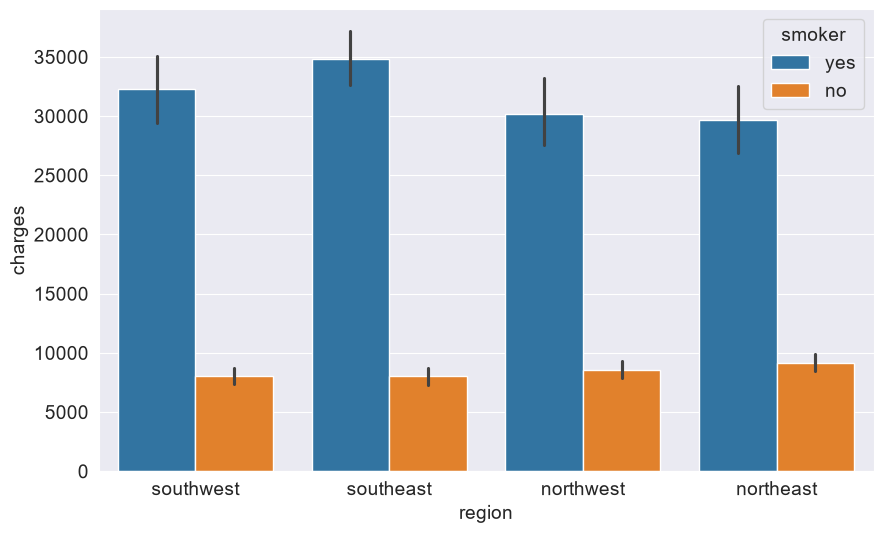

In [22]:
# Relationship between charges and region
fig = sns.barplot(medical_df, x='region', y='charges', hue='smoker')
plt.show()

In [23]:
# Relationship between charges and smoker
px.violin(medical_df, x='smoker', y='charges', color='sex', title='Charges vs. Smoker')

Correlation

In [24]:
medical_df['charges'].corr(medical_df['age'])

np.float64(0.2990081933306478)

In [25]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362887)

In [26]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790487)

In [27]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984778)

In [28]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

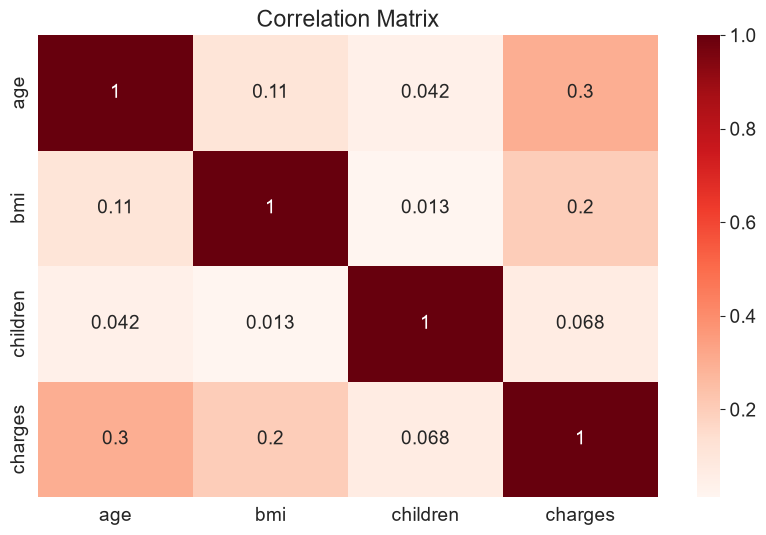

In [29]:
sns.heatmap(medical_df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Matrix')

Estimating charges using age of non-smokers(Linear Regression)

In [30]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

<Axes: xlabel='age', ylabel='charges'>

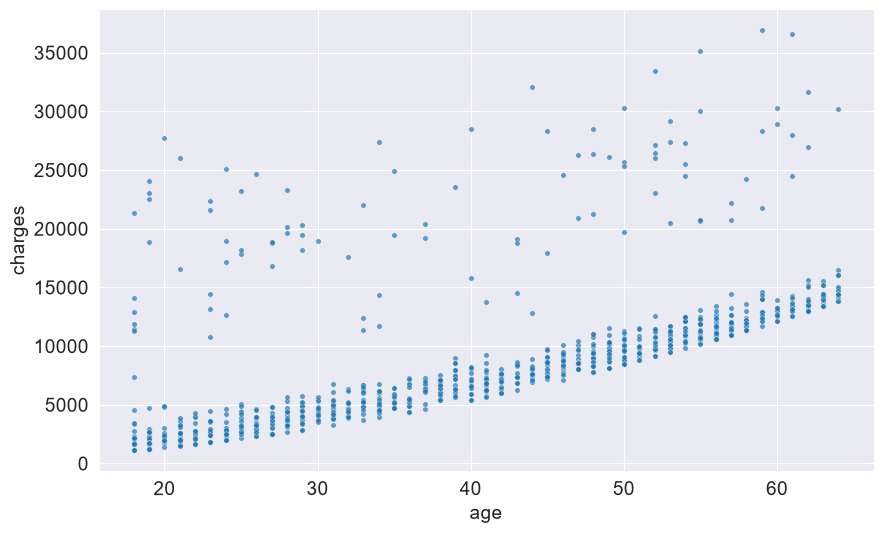

In [31]:
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15)

In [32]:
def estimate_charges(age, w, b):
  return w * age + b

In [33]:
w = 50
b = 100

estimate_charges(30, w, b)

1600

In [34]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages, w, b)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [35]:
def try_parameters(w, b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges

  estimated_charges = estimate_charges(ages, w, b)

  plt.plot(ages, estimated_charges, 'r', alpha=0.9)
  plt.scatter(ages, target, s=8, alpha=0.8)
  plt.xlabel('Age')
  plt.ylabel('Charges')
  plt.legend(['Estimate', 'Actual'])

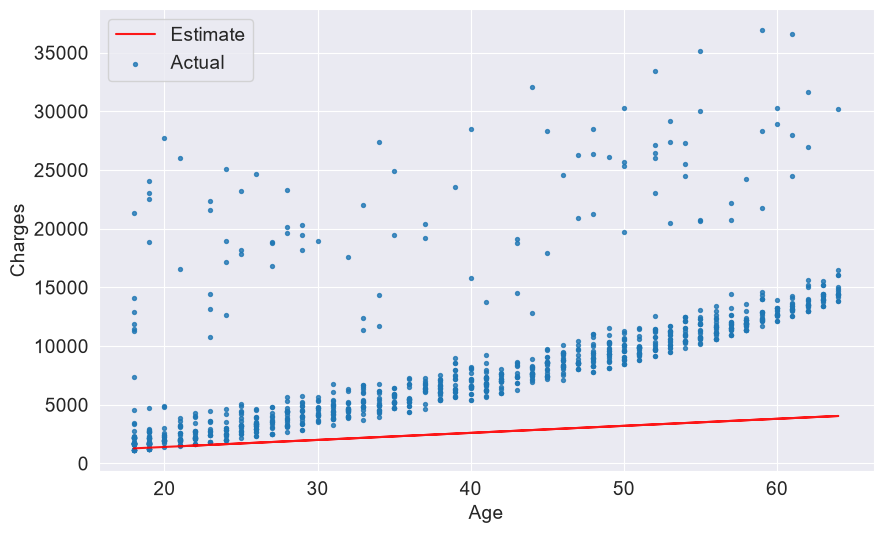

In [36]:
try_parameters(60, 200)

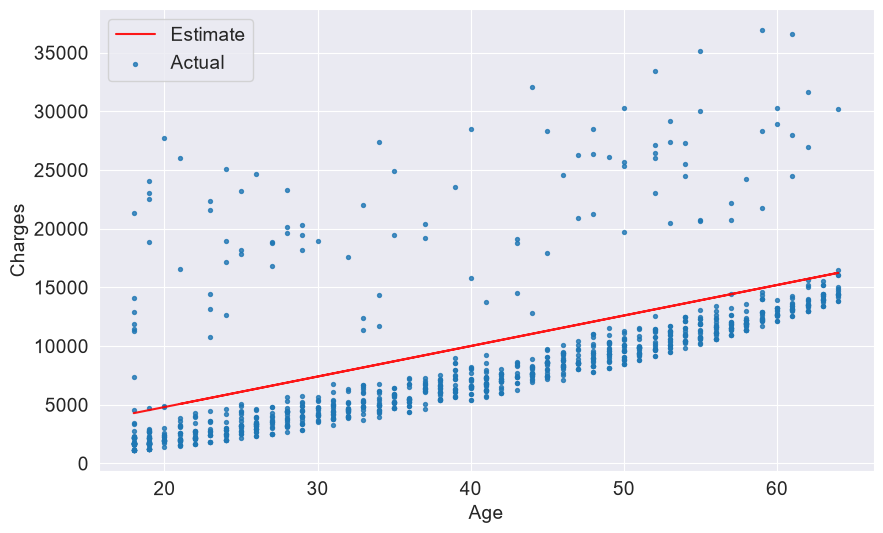

In [37]:
try_parameters(260, -400)

In [38]:
targets = non_smoker_df.charges
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [39]:
predictions = estimated_charges
predictions

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [40]:
import numpy as np

In [ ]:
# Calculate the root mean squared error of the model
def rmse(targets, predictions):
  return np.sqrt(np.mean(np.square(targets-predictions)))

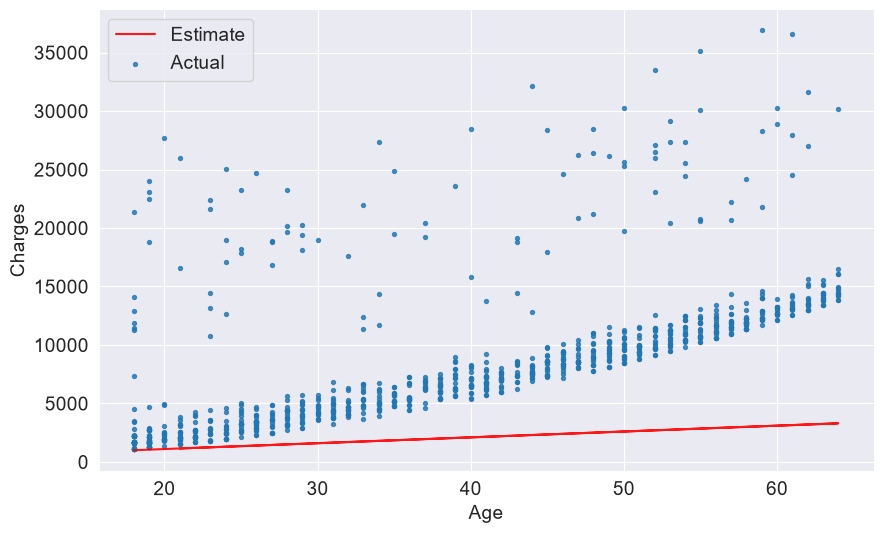

In [42]:
w = 50
b = 100
try_parameters(w, b)

In [45]:
predicted = estimate_charges(non_smoker_df['age'], w, b)
predicted

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [44]:
rmse(targets, predicted)

np.float64(8461.949562575493)

In [46]:
# Modify try_parameters() to show the loss
def try_parameters(w, b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges
  predictions = estimate_charges(ages, w, b)

  plt.plot(ages, predictions, 'r', alpha=0.9)
  plt.scatter(ages, target, s=8, alpha=0.8)
  plt.xlabel('Age')
  plt.ylabel('Charges')
  plt.legend(['Prediction', 'Actual'])

  loss = rmse(target, predictions)
  print('RMSE loss: ', loss)

RMSE loss:  8461.949562575493


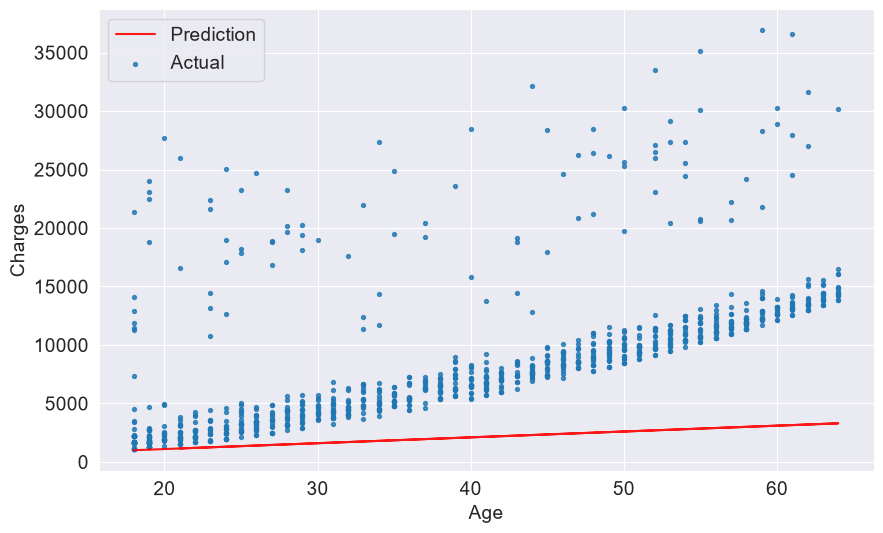

In [47]:
try_parameters(50, 100)

RMSE loss:  4956.973980899423


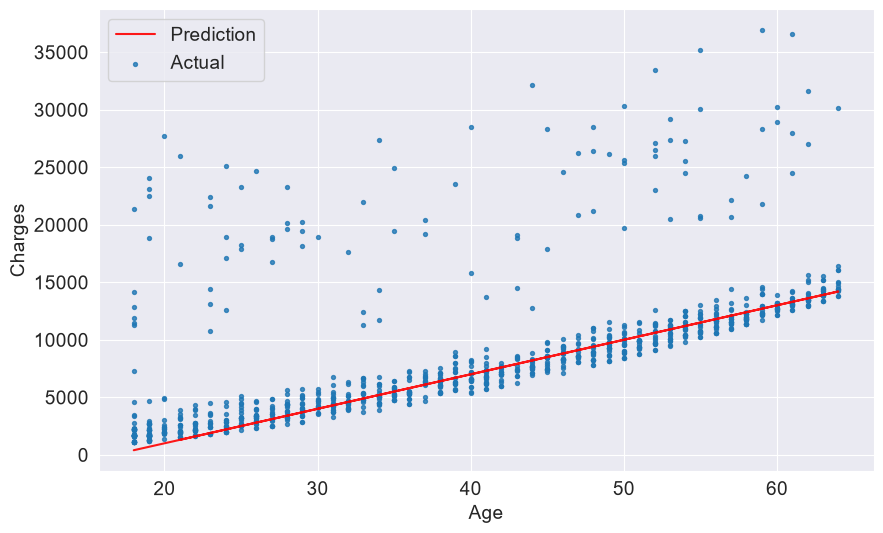

In [54]:
try_parameters(300, -5000)

Linear Regression using Scikit Learn

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
model = LinearRegression()

In [57]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges

In [58]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[267.25]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2091
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [60]:
model.predict(np.array([[23], [37], [61]]))

d:\Documents\Coding Prac\ML Projects\Predicting medical expenses using linear regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [ ]:
# Charges predictions for non-smokers based on age
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [62]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [63]:
# slope
model.coef_

array([267.24891283])

In [64]:
# intercept
model.intercept_

np.float64(-2091.4205565650864)

RMSE loss:  4662.505766636395


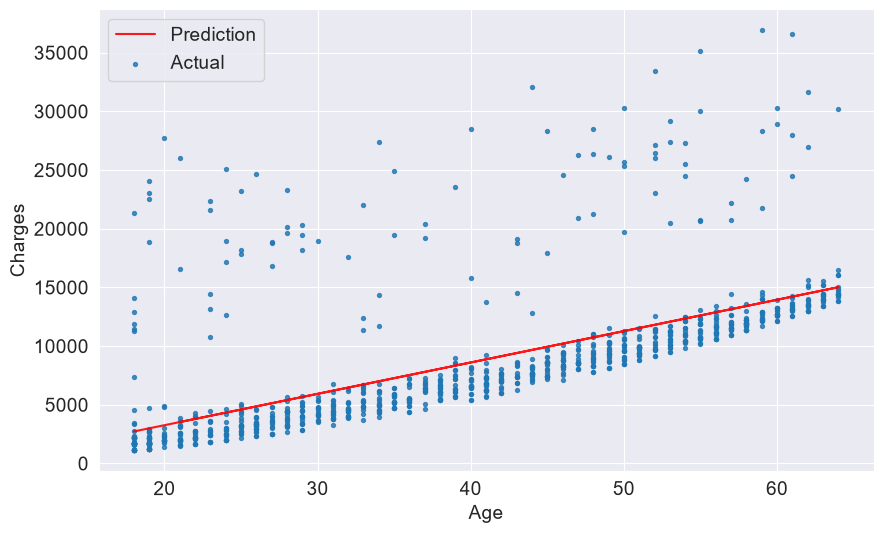

In [65]:
try_parameters(model.coef_, model.intercept_)

In [66]:
# Using gradient descent technique to train the model
from sklearn.linear_model import SGDRegressor

model_g = SGDRegressor()
model_g

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [69]:
model_g.fit(inputs, targets)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [71]:
predictions = model_g.predict(inputs)
predictions

array([1581.13848066, 5975.6330695 , 8172.88036392, ..., 1581.13848066,
       1581.13848066, 2899.48685732], shape=(1064,))

In [73]:
rmse(targets, predictions)

np.float64(5838.6734085863045)

In [74]:
model_g.coef_

array([439.44945888])

In [75]:
model_g.intercept_

array([-6328.95177924])

RMSE loss:  5838.6734085863045


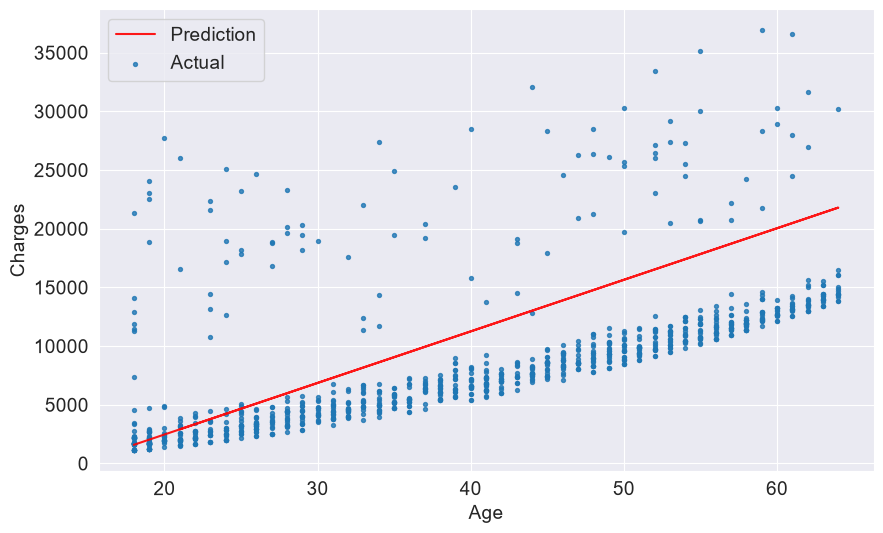

In [76]:
try_parameters(model_g.coef_, model_g.intercept_)

Estimating medical charges for smokers based on age

In [79]:
smokers_df = medical_df[medical_df['smoker'] == 'yes']

<Axes: xlabel='age', ylabel='charges'>

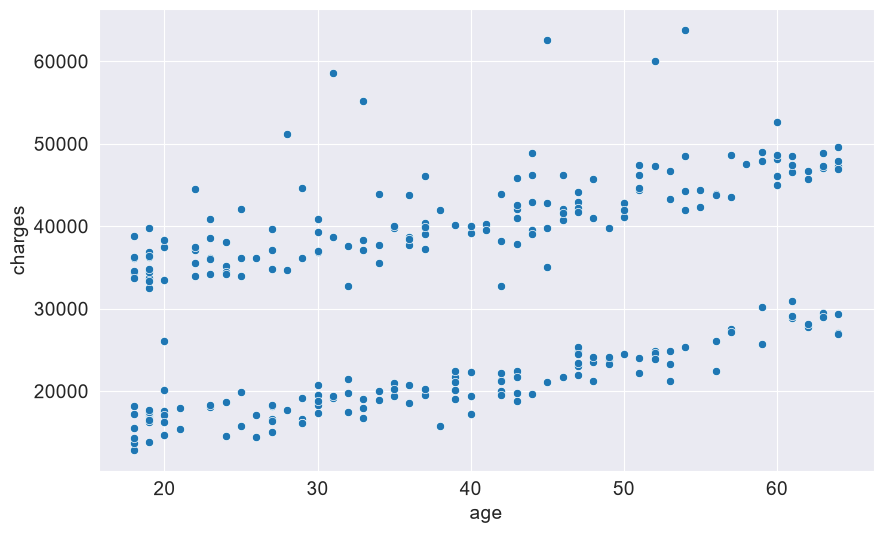

In [80]:
sns.scatterplot(smokers_df, x='age', y='charges')

In [81]:
age_smoker_model = LinearRegression()

In [85]:
age_inputs = smokers_df[['age']]
charges_targets = smokers_df['charges']
age_smoker_model.fit(age_inputs, charges_targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[305.24]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.029e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [87]:
predictions = age_smoker_model.predict(age_inputs)
predictions

array([26093.642567  , 39218.85945773, 28535.54338388, 29451.25619021,
       30672.20659865, 29756.49379232, 27009.35537333, 28840.78098599,
       30977.44420076, 38608.38425351, 31282.68180287, 34945.53302819,
       31282.68180287, 37997.90904929, 25788.40496489, 36471.72103874,
       26398.88016911, 28840.78098599, 28535.54338388, 27009.35537333,
       31587.91940498, 34029.82022186, 37692.67144718, 38303.1466514 ,
       39829.33466195, 37387.43384507, 31893.15700709, 38913.62185562,
       26398.88016911, 39524.09705984, 29146.0185881 , 33724.58261975,
       26093.642567  , 30061.73139443, 30672.20659865, 29451.25619021,
       34335.05782397, 33114.10741553, 34945.53302819, 25788.40496489,
       29451.25619021, 33114.10741553, 25788.40496489, 39524.09705984,
       31282.68180287, 28535.54338388, 30977.44420076, 26093.642567  ,
       33114.10741553, 32503.63221131, 26093.642567  , 27314.59297544,
       39524.09705984, 25788.40496489, 39524.09705984, 36776.95864085,
      

In [88]:
charges_targets

0       16884.92400
11      27808.72510
14      39611.75770
19      36837.46700
23      37701.87680
           ...     
1313    36397.57600
1314    18765.87545
1321    28101.33305
1323    43896.37630
1337    29141.36030
Name: charges, Length: 274, dtype: float64

In [89]:
rmse(charges_targets, predictions)

np.float64(10711.00334810241)

In [91]:
age_smoker_model.coef_

array([305.23760211])

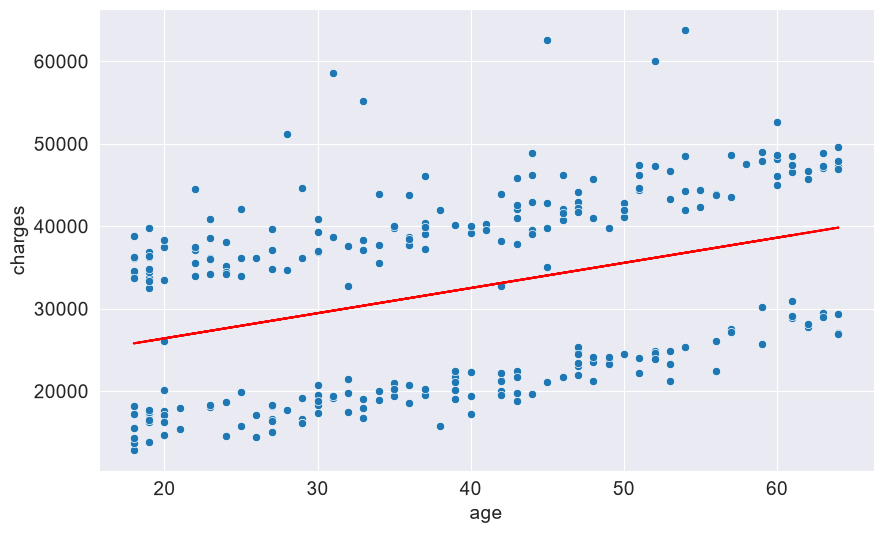

In [94]:
sns.scatterplot(smokers_df, x='age', y='charges')
predictions = estimate_charges(smokers_df['age'], age_smoker_model.coef_, age_smoker_model.intercept_)
plt.plot(smokers_df['age'], predictions, 'r')
plt.show()

Estimate charges using age and bmi for non-smokers

In [99]:
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']
age_bmi_model = LinearRegression().fit(inputs, targets)
predictions = age_bmi_model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss: ', loss)

Loss:  4662.3128354612945


In [100]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.08403654312833271)

In [101]:
fig = px.scatter(non_smoker_df, x='bmi', y='charges', title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [102]:
age_bmi_model.coef_, age_bmi_model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

Estimate the charges based on No. of children, age and bmi for non-smokers

In [103]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542205)

In [104]:
fig = px.strip(non_smoker_df, x='children', y='charges', title='Children vs. Charges')
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

In [106]:
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']
age_bmi_child_model = LinearRegression().fit(inputs, targets)
predictions = age_bmi_child_model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss: ', loss)

Loss:  4608.470405038246


Estimate medical charges for smokers based on age, bmi and children

In [113]:
smokers_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.059674,0.081183,0.368224
bmi,0.059674,1.000000,-0.012619,0.806481
children,0.081183,-0.012619,1.000000,0.035945
charges,0.368224,0.806481,0.035945,1.000000


In [118]:
inputs, target = smokers_df[['age', 'bmi', 'children']], smokers_df['charges']
age_bmi_child_s_model = LinearRegression().fit(inputs, target)
predictions = age_bmi_child_s_model.predict(inputs)

loss = rmse(target, predictions)
loss

np.float64(5718.202480524154)

Text(0, 0.5, 'Predicted charges')

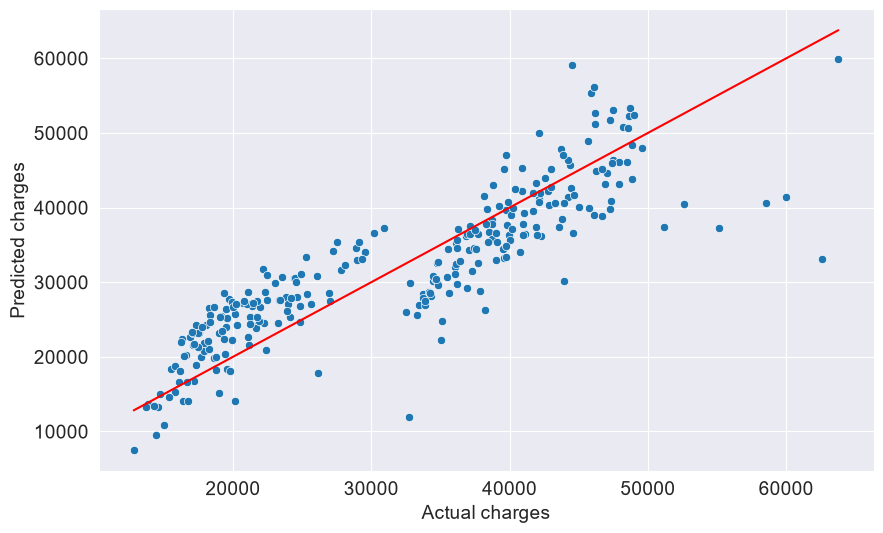

In [ ]:
# Visualize the targets and predictions
sns.scatterplot(x=target, y=predictions)
plt.plot([target.min(), target.max()], [target.min(), target.max()], 'r')
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')

Estimate medical charges for all customers

In [150]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [153]:
medical_df['charges']

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [152]:
inputs, target = medical_df[['age', 'bmi', 'children']], medical_df['charges']

age_bmi_child_all_model = LinearRegression().fit(inputs, target)
predictions = age_bmi_child_all_model.predict(inputs)
predictions

array([ 6908.77753344,  9160.97706103, 12390.94691779, ...,
        9640.92917145,  6691.39141657, 17377.08299024], shape=(1338,))

In [154]:
loss = rmse(target, predictions)
loss

np.float64(11355.317901125973)

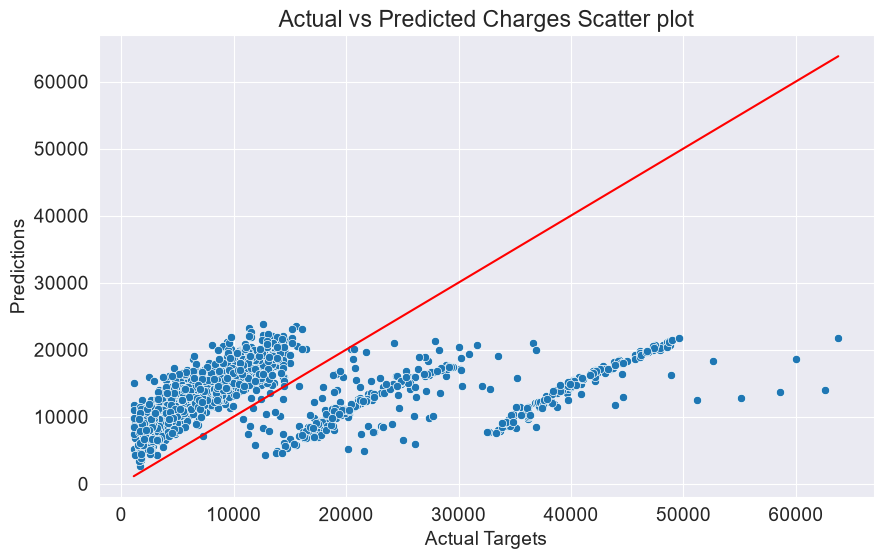

In [158]:
sns.scatterplot(x=target, y=predictions)
plt.plot([target.min(), target.max()], [target.min(), target.max()], 'r')
plt.xlabel('Actual Targets')
plt.ylabel('Predictions')
plt.title('Actual vs Predicted Charges Scatter plot')
plt.show()


Binary Categories

<Axes: xlabel='smoker', ylabel='charges'>

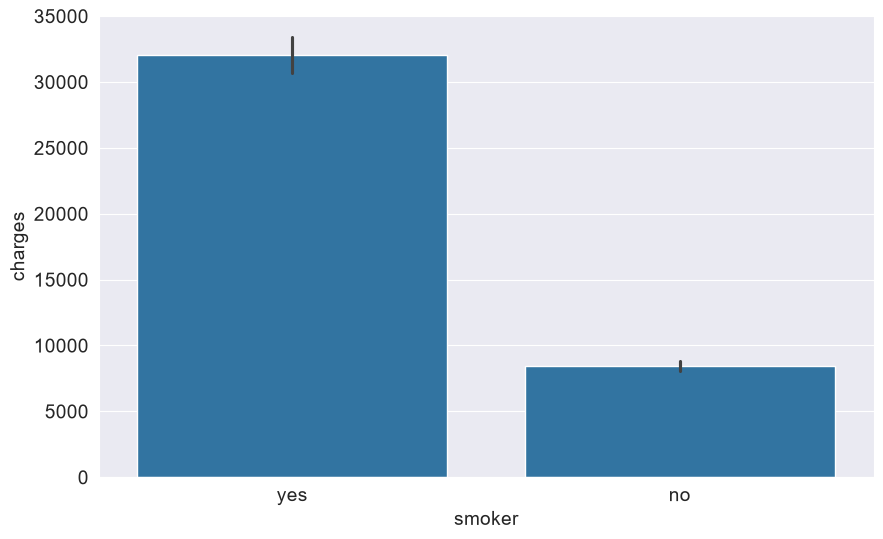

In [161]:
sns.barplot(medical_df, x='smoker', y='charges')

In [163]:
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df['smoker'].map(smoker_codes)

In [165]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [164]:
medical_df['charges'].corr(medical_df.smoker_code)

np.float64(0.7872514304984778)

In [ ]:
# Estimating the charges with the smokers category added
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

model_smoker = LinearRegression().fit(inputs, target)
predictions = model_smoker.predict(inputs)
loss = rmse(targets, predictions)
loss

np.float64(6056.439217188081)

<Axes: xlabel='sex', ylabel='charges'>

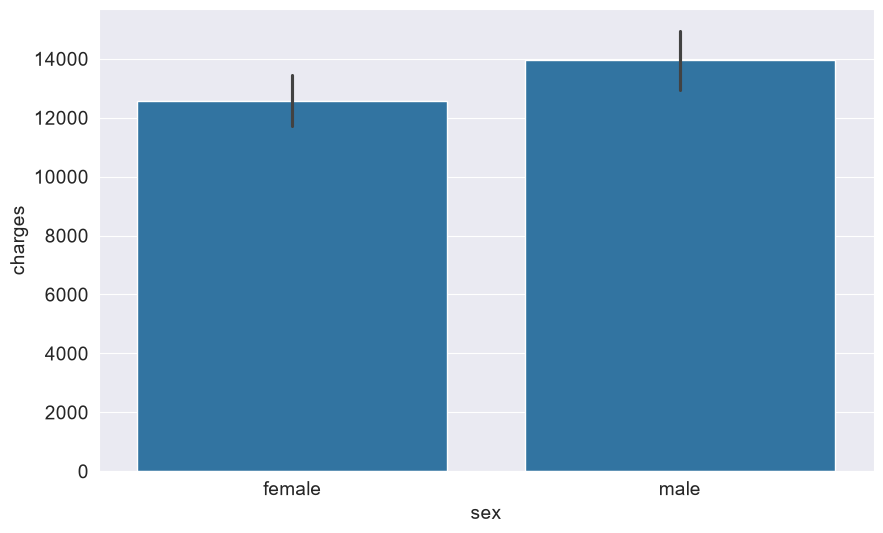

In [168]:
sns.barplot(medical_df, x='sex', y='charges')

In [169]:
sex_codes = {'female': 0, 'male': 1}

In [170]:
medical_df['sex_codes'] = medical_df['sex'].map(sex_codes)
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [171]:
medical_df.charges.corr(medical_df.sex_codes)

np.float64(0.05729206220202533)

In [ ]:
# Estimating the charges with the sex added
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_codes']], medical_df['charges']

model_sex = LinearRegression().fit(inputs, target)
predictions = model_sex.predict(inputs)
loss = rmse(targets, predictions)
loss

np.float64(6056.100708754546)

<Axes: xlabel='region', ylabel='charges'>

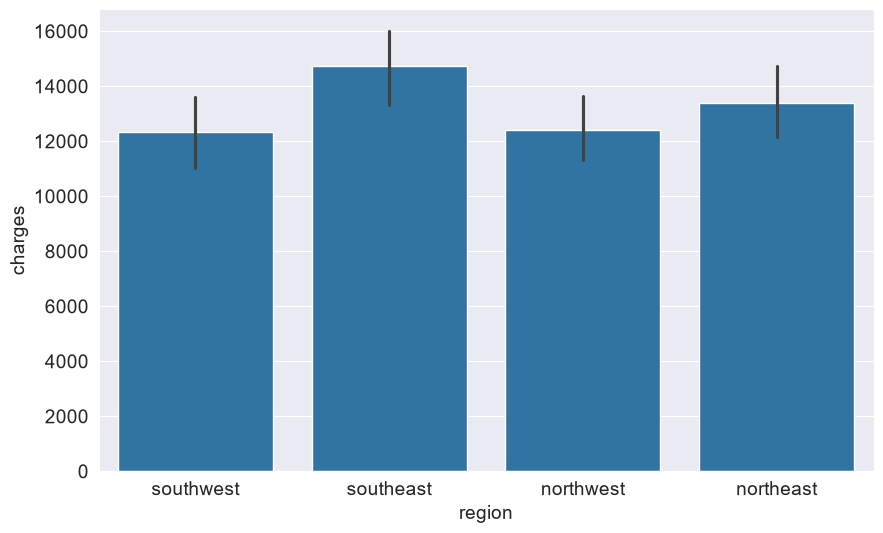

In [174]:
sns.barplot(medical_df, x='region', y='charges')

In [179]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
encoded = enc.fit_transform(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [180]:
one_hot = encoded.toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [182]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_codes,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [187]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges,smoker_code,sex_codes,northeast,northwest,southeast,southwest
age,1.000000,0.109272,0.042469,0.299008,-0.025019,-0.020856,0.002475,-0.000407,-0.011642,0.010016
bmi,0.109272,1.000000,0.012759,0.198341,0.003750,0.046371,-0.138156,-0.135996,0.270025,-0.006205
children,0.042469,0.012759,1.000000,0.067998,0.007673,0.017163,-0.022808,0.024806,-0.023066,0.021914
charges,0.299008,0.198341,0.067998,1.000000,0.787251,0.057292,0.006349,-0.039905,0.073982,-0.043210
smoker_code,-0.025019,0.003750,0.007673,0.787251,1.000000,0.076185,0.002811,-0.036945,0.068498,-0.036945
sex_codes,-0.020856,0.046371,0.017163,0.057292,0.076185,1.000000,-0.002425,-0.011156,0.017117,-0.004184
northeast,0.002475,-0.138156,-0.022808,0.006349,0.002811,-0.002425,1.000000,-0.320177,-0.345561,-0.320177
northwest,-0.000407,-0.135996,0.024806,-0.039905,-0.036945,-0.011156,-0.320177,1.000000,-0.346265,-0.320829
southeast,-0.011642,0.270025,-0.023066,0.073982,0.068498,0.017117,-0.345561,-0.346265,1.000000,-0.346265
southwest,0.010016,-0.006205,0.021914,-0.043210,-0.036945,-0.004184,-0.320177,-0.320829,-0.346265,1.000000


In [188]:
# Estimate charges with the regions added
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_codes', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

model_regions = LinearRegression().fit(inputs, targets)
predictions = model_regions.predict(inputs)

loss = rmse(targets, predictions)
loss

np.float64(6041.6796511744515)

In [199]:
# Estimate charges for smokers and non smokers
input_cols_wo_smoker = ['age', 'bmi', 'children', 'sex_codes', 'northeast', 'northwest', 'southeast', 'southwest']
smoker_df_enc = medical_df[medical_df['smoker'] == 'yes']
non_smoker_df_enc = medical_df[medical_df['smoker'] == 'no']

def get_predictions_targets(df):
  inputs, targets = df[input_cols_wo_smoker], df['charges']
  model_upd = LinearRegression().fit(inputs, targets)
  predictions = model_upd.predict(inputs)
  return targets, predictions, model_upd

smoker_targets, smoker_predictions, model_upd = get_predictions_targets(smoker_df_enc)
smoker_loss = rmse(smoker_targets, smoker_predictions)
non_smoker_targets, non_smoker_predictions, model_upd = get_predictions_targets(non_smoker_df_enc)
non_smoker_loss = rmse(non_smoker_targets, non_smoker_predictions)
print('Smokers Error: ', smoker_loss)
print('Non Smokers Error: ', non_smoker_loss)


Smokers Error:  5668.4678821121515
Non Smokers Error:  4573.074988795492


In [202]:
model_regions.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

Feature Scaling

In [203]:
from sklearn.preprocessing import StandardScaler

In [204]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [205]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [206]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [207]:
medical_df[numeric_cols]

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0
...,...,...,...
1333,50,30.970,3
1334,18,31.920,0
1335,18,36.850,0
1336,21,25.800,0


In [208]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))

In [211]:
cat_cols = ['smoker_code', 'sex_codes', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values
categorical_data

array([[1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 0.]], shape=(1338, 6))

In [212]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = medical_df.charges

model = LinearRegression().fit(inputs, target)
predictions = model.predict(inputs)

loss = rmse(targets, predictions)
loss

np.float64(6041.679651174452)

In [215]:
weights_df = pd.DataFrame({
  'feature': np.append(numeric_cols + cat_cols, 1), 
  'weight': np.append(model.coef_, model.intercept_)
})

weights_df.sort_values('weight', ascending=False)

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_codes,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


Creating a test set

In [219]:
from sklearn.model_selection import train_test_split

In [220]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1)

In [221]:
model = LinearRegression().fit(inputs_train, targets_train)

predictions_test = model.predict(inputs_test)

loss = rmse(targets_test, predictions_test)
loss

np.float64(6482.266945303928)

In [222]:
predictions_train = model.predict(inputs_train)
loss = rmse(targets_train, predictions_train)
loss

np.float64(5993.699149926612)

Estimating charges for a customer

In [216]:
new_customer = [[28, 30, 2, 1, 0, 0, 1, 0, 0.]]

In [217]:
scaler.transform([[28, 30, 2]])

d:\Documents\Coding Prac\ML Projects\Predicting medical expenses using linear regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.79795355, -0.10882659,  0.75107928]])

In [218]:
model.predict([[-0.79795355, -0.10882659,  0.75107928, 1, 0, 0, 1, 0, 0.]])

array([29875.81463371])